# Storytelling

- Looking at the past modeling and zeroing into one of the situations for something to storytell.
- Look at the red-zone types, 2-minute drill, what sort of routes are doing the best against coverages. Showcasing only the red-zone data.
- Have a dashboard to showcase with the paper:
  - Input the route, coverage, and showcase the data for that.
  - Put in the physical metrics.
  - This is the dashboard that could be showcased with sorting characteristics.
  - It should be able to predict the last weeks of this year for those two minute drills or redzone opportunities. 

In [18]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load supplementary data first to understand the context
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\raw\\supplementary_data.csv')

# Data Engineering:

In [19]:
# Now let's identify 2-minute drill and red-zone situations
# 2-minute drill: last 2 minutes of each half (quarters 2 and 4)
# Red-zone: within 20 yards of the end zone

def parse_game_clock(clock_str):
    """Convert game clock string to seconds"""
    try:
        parts = clock_str.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

supp_data['game_clock_seconds'] = supp_data['game_clock'].apply(parse_game_clock)

# Identify 2-minute drill situations
supp_data['is_two_minute_drill'] = (
    ((supp_data['quarter'] == 2) | (supp_data['quarter'] == 4)) & 
    (supp_data['game_clock_seconds'] <= 120)
)

# Identify red-zone situations (within 20 yards of end zone)
# yardline_number represents distance from the yardline_side's goal
# We need to calculate absolute yardline
def calculate_absolute_yardline(row):
    """Calculate yards to go for touchdown"""
    if pd.isna(row['yardline_number']):
        return None
    # If yardline_side is the possession team, they're going away from their own goal
    # If yardline_side is the defensive team, they're close to scoring
    if row['yardline_side'] == row['possession_team']:
        return 100 - row['yardline_number']
    else:
        return row['yardline_number']

supp_data['yards_to_endzone'] = supp_data.apply(calculate_absolute_yardline, axis=1)
supp_data['is_redzone'] = supp_data['yards_to_endzone'] <= 20

print("2-Minute Drill Situations:", supp_data['is_two_minute_drill'].sum())
print("Red-Zone Situations:", supp_data['is_redzone'].sum())
print("\nOverlap (Both 2-min and Red-zone):", 
      ((supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])).sum())

# Create completion binary variable
supp_data['is_completion'] = (supp_data['pass_result'] == 'C').astype(int)

print("\n=== COMPLETION RATES ===")
print(f"Overall: {supp_data['is_completion'].mean():.3f}")
print(f"2-Minute Drill: {supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean():.3f}")
print(f"Red-Zone: {supp_data[supp_data['is_redzone']]['is_completion'].mean():.3f}")
print(f"Both: {supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean():.3f}")

# Save this enhanced supplementary data
supp_data.to_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\processed\\supplementary_enhanced.csv', index=False)

2-Minute Drill Situations: 2762
Red-Zone Situations: 2146

Overlap (Both 2-min and Red-zone): 383

=== COMPLETION RATES ===
Overall: 0.692
2-Minute Drill: 0.673
Red-Zone: 0.623
Both: 0.593


In [20]:
# Load all input and output files and merge with supplementary data
# Define the base path
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')

# Alternative: if the above doesn't work, try without the project folder name
# BASE_PATH = Path('data/raw')

# Load all weeks using pathlib for cross-platform compatibility
all_input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))
all_output_files = sorted(BASE_PATH.glob('output_2023_w*.csv'))

# Convert Path objects to strings for pandas
all_input_files = [str(f) for f in all_input_files]
all_output_files = [str(f) for f in all_output_files]

print(f"Found {len(all_input_files)} input files")
print(f"Found {len(all_output_files)} output files")

if len(all_input_files) > 0:
    print("\nInput files found:")
    for f in all_input_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_input_files) > 5:
        print(f"  ... and {len(all_input_files) - 5} more")

if len(all_output_files) > 0:
    print("\nOutput files found:")
    for f in all_output_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_output_files) > 5:
        print(f"  ... and {len(all_output_files) - 5} more")

# For feature engineering, we need to extract features from the last frame before pass
# Let's process week 1 as an example first

if len(all_input_files) > 0:
    # Load week 1 input
    print(f"\nLoading {Path(all_input_files[0]).name}...")
    input_w1 = pd.read_csv(all_input_files[0])

    def extract_features_from_tracking(input_df):
        """Extract features from tracking data at the last frame before pass"""
        # Get the last frame for each player in each play
        last_frames = input_df.groupby(['game_id', 'play_id', 'nfl_id']).tail(1)
        
        # Calculate additional features
        features = last_frames.copy()
        
        # Distance to ball landing spot
        features['dist_to_ball_land'] = np.sqrt(
            (features['x'] - features['ball_land_x'])**2 + 
            (features['y'] - features['ball_land_y'])**2
        )
        
        # Speed and acceleration features
        features['speed_x_accel'] = features['s'] * features['a']
        
        return features

    # Process week 1
    week1_features = extract_features_from_tracking(input_w1)

    print("\nExtracted features shape:", week1_features.shape)
    print("\nFeatures for targeted receivers:")
    targeted = week1_features[week1_features['player_role'] == 'Targeted Receiver']
    print(f"Targeted receivers: {len(targeted)}")
    print("\nSample features:")
    print(targeted[['game_id', 'play_id', 'player_name', 'x', 'y', 's', 'a', 
                   'dist_to_ball_land', 'ball_land_x', 'ball_land_y']].head())
    
else:
    print("\n❌ No input files found.")

Found 18 input files
Found 18 output files

Input files found:
  - input_2023_w01.csv
  - input_2023_w02.csv
  - input_2023_w03.csv
  - input_2023_w04.csv
  - input_2023_w05.csv
  ... and 13 more

Output files found:
  - output_2023_w01.csv
  - output_2023_w02.csv
  - output_2023_w03.csv
  - output_2023_w04.csv
  - output_2023_w05.csv
  ... and 13 more

Loading input_2023_w01.csv...

Extracted features shape: (10089, 25)

Features for targeted receivers:
Targeted receivers: 819

Sample features:
         game_id  play_id        player_name      x      y     s     a  \
233   2023090700      101      Josh Reynolds  52.43  14.14  7.90  2.68   
649   2023090700      194    Jerick McKinnon  88.98  22.23  6.09  2.14   
870   2023090700      219          Noah Gray  75.98  10.22  3.85  2.77   
1431  2023090700      361       Marvin Jones  34.19  48.33  1.51  3.87   
1651  2023090700      436  Amon-Ra St. Brown  33.67  37.80  3.59  6.08   

      dist_to_ball_land  ball_land_x  ball_land_y  
23

Comprehensive analysis visualization saved!


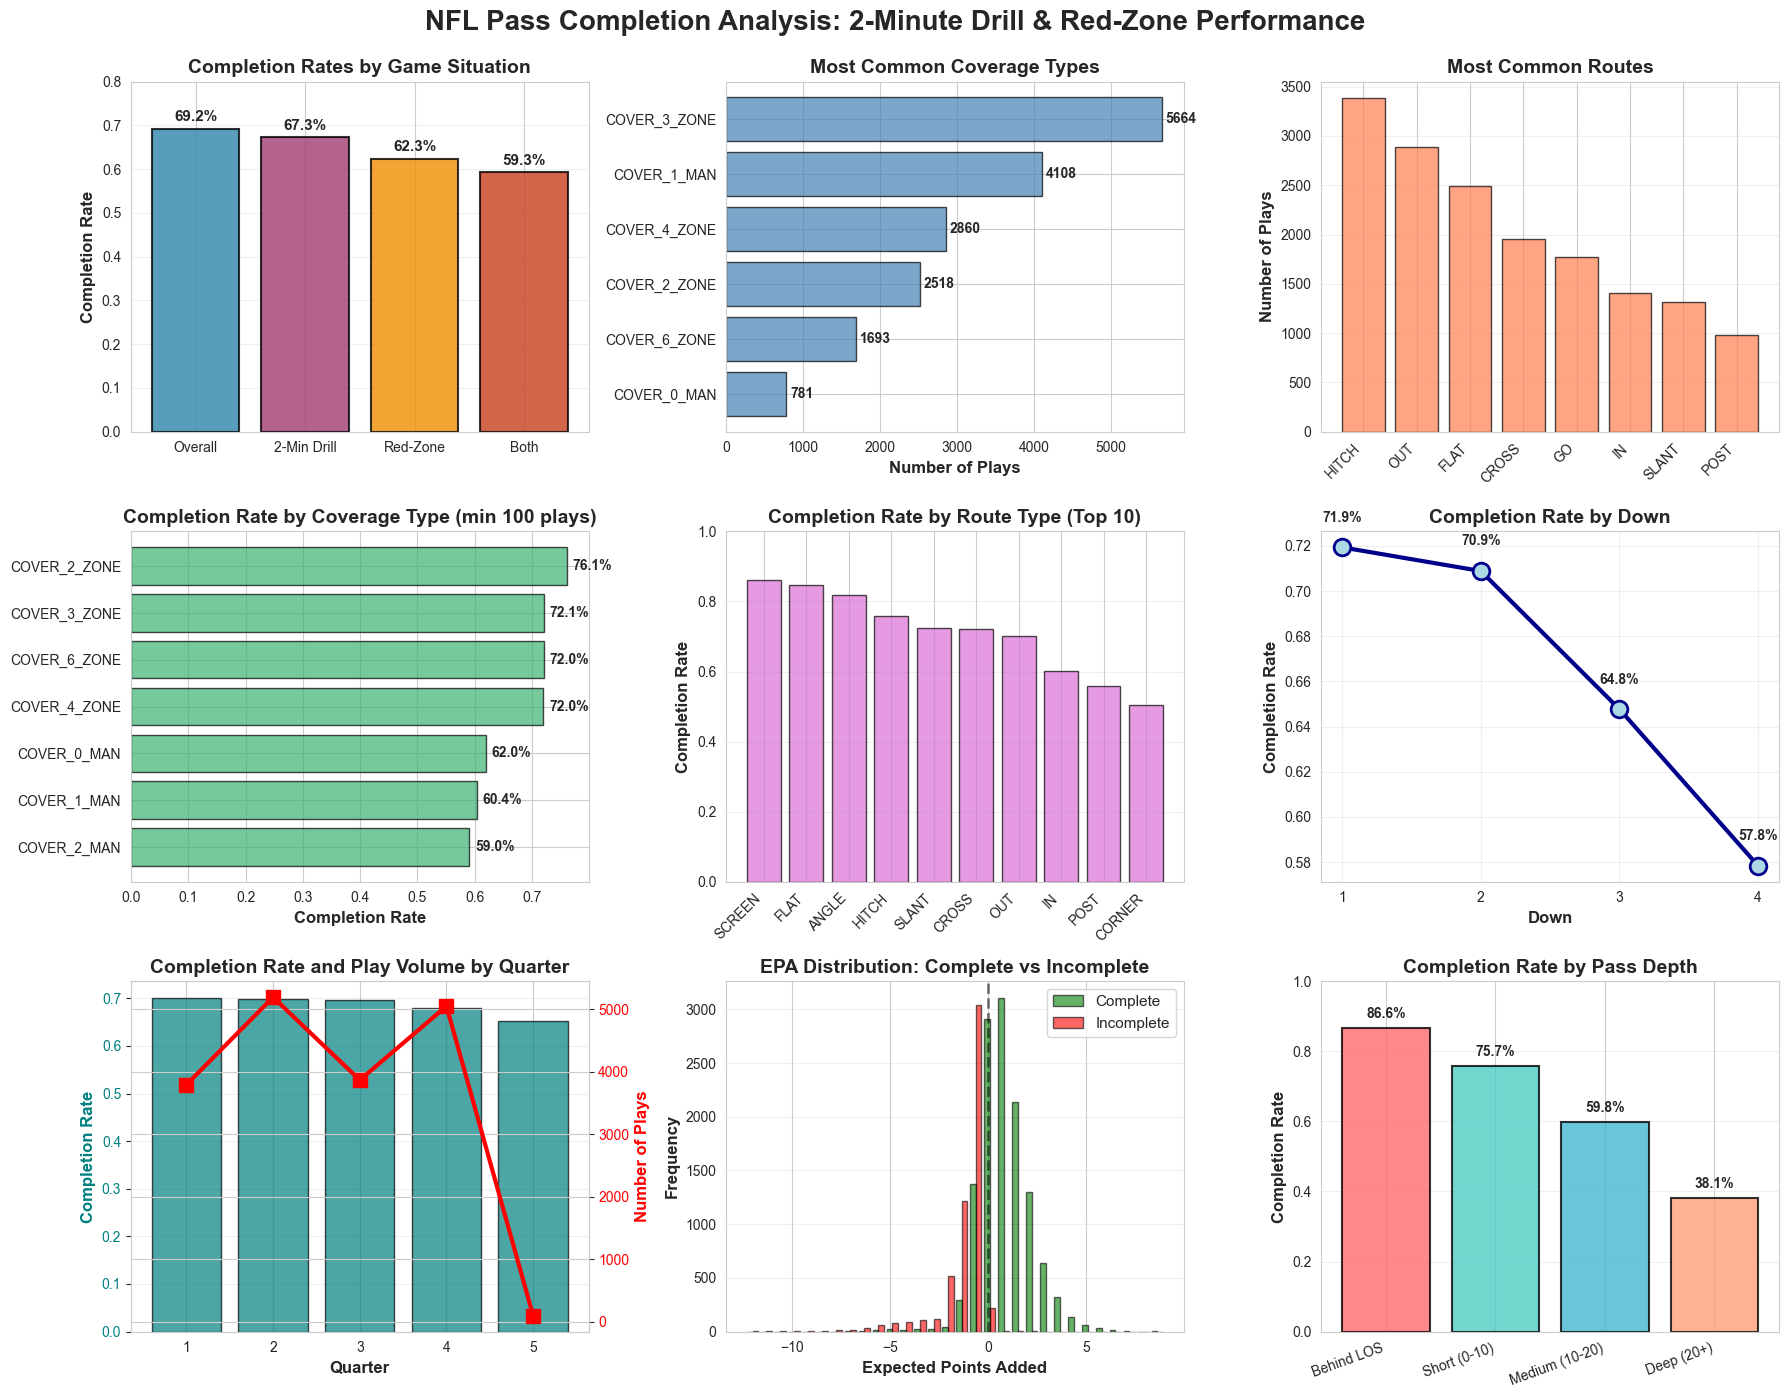

In [21]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('NFL Pass Completion Analysis: 2-Minute Drill & Red-Zone Performance', 
             fontsize=20, fontweight='bold', y=0.995)

# 1. Completion Rates by Situation
ax1 = axes[0, 0]
situations = ['Overall', '2-Min Drill', 'Red-Zone', 'Both']
completion_rates = [
    supp_data['is_completion'].mean(),
    supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean(),
    supp_data[supp_data['is_redzone']]['is_completion'].mean(),
    supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean()
]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax1.bar(situations, completion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax1.set_title('Completion Rates by Game Situation', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 0.8)
for i, (bar, rate) in enumerate(zip(bars, completion_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Coverage Type Distribution
ax2 = axes[0, 1]
coverage_counts = supp_data['team_coverage_type'].value_counts().head(6)
ax2.barh(coverage_counts.index, coverage_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Plays', fontsize=12, fontweight='bold')
ax2.set_title('Most Common Coverage Types', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(coverage_counts.values):
    ax2.text(v + 50, i, str(v), va='center', fontsize=10, fontweight='bold')

# 3. Route Distribution
ax3 = axes[0, 2]
route_counts = supp_data['route_of_targeted_receiver'].value_counts().head(8)
ax3.bar(range(len(route_counts)), route_counts.values, color='coral', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(route_counts)))
ax3.set_xticklabels(route_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Number of Plays', fontsize=12, fontweight='bold')
ax3.set_title('Most Common Routes', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Completion Rate by Coverage Type
ax4 = axes[1, 0]
coverage_completion = supp_data.groupby('team_coverage_type')['is_completion'].agg(['mean', 'count'])
coverage_completion = coverage_completion[coverage_completion['count'] >= 100].sort_values('mean', ascending=False)
ax4.barh(coverage_completion.index, coverage_completion['mean'], color='mediumseagreen', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Completion Rate', fontsize=12, fontweight='bold')
ax4.set_title('Completion Rate by Coverage Type (min 100 plays)', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(coverage_completion['mean']):
    ax4.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10, fontweight='bold')

# 5. Completion Rate by Route
ax5 = axes[1, 1]
route_completion = supp_data.groupby('route_of_targeted_receiver')['is_completion'].agg(['mean', 'count'])
route_completion = route_completion[route_completion['count'] >= 100].sort_values('mean', ascending=False).head(10)
ax5.bar(range(len(route_completion)), route_completion['mean'], color='orchid', alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(route_completion)))
ax5.set_xticklabels(route_completion.index, rotation=45, ha='right')
ax5.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax5.set_title('Completion Rate by Route Type (Top 10)', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)

# 6. Down and Distance Analysis
ax6 = axes[1, 2]
down_completion = supp_data.groupby('down')['is_completion'].mean()
ax6.plot(down_completion.index, down_completion.values, marker='o', linewidth=3, 
         markersize=12, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
ax6.set_xlabel('Down', fontsize=12, fontweight='bold')
ax6.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax6.set_title('Completion Rate by Down', fontsize=14, fontweight='bold')
ax6.set_xticks([1, 2, 3, 4])
ax6.grid(True, alpha=0.3)
for x, y in zip(down_completion.index, down_completion.values):
    ax6.text(x, y + 0.01, f'{y:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 7. Quarter Analysis
ax7 = axes[2, 0]
quarter_data = supp_data.groupby('quarter').agg({
    'is_completion': 'mean',
    'play_id': 'count'
})
ax7_twin = ax7.twinx()
bars = ax7.bar(quarter_data.index, quarter_data['is_completion'], color='teal', alpha=0.7, 
               edgecolor='black', label='Completion Rate')
line = ax7_twin.plot(quarter_data.index, quarter_data['play_id'], color='red', marker='s', 
                     linewidth=3, markersize=10, label='Number of Plays')
ax7.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax7.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='teal')
ax7_twin.set_ylabel('Number of Plays', fontsize=12, fontweight='bold', color='red')
ax7.set_title('Completion Rate and Play Volume by Quarter', fontsize=14, fontweight='bold')
ax7.tick_params(axis='y', labelcolor='teal')
ax7_twin.tick_params(axis='y', labelcolor='red')
ax7.grid(axis='y', alpha=0.3)

# 8. Expected Points Added Distribution
ax8 = axes[2, 1]
epa_complete = supp_data[supp_data['is_completion'] == 1]['expected_points_added'].dropna()
epa_incomplete = supp_data[supp_data['is_completion'] == 0]['expected_points_added'].dropna()
ax8.hist([epa_complete, epa_incomplete], bins=30, label=['Complete', 'Incomplete'], 
         color=['green', 'red'], alpha=0.6, edgecolor='black')
ax8.set_xlabel('Expected Points Added', fontsize=12, fontweight='bold')
ax8.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax8.set_title('EPA Distribution: Complete vs Incomplete', fontsize=14, fontweight='bold')
ax8.legend(fontsize=11)
ax8.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax8.grid(axis='y', alpha=0.3)

# 9. Pass Length Analysis
ax9 = axes[2, 2]
pass_length_bins = pd.cut(supp_data['pass_length'], bins=[-50, 0, 10, 20, 100], 
                          labels=['Behind LOS', 'Short (0-10)', 'Medium (10-20)', 'Deep (20+)'])
length_completion = supp_data.groupby(pass_length_bins)['is_completion'].mean()
ax9.bar(range(len(length_completion)), length_completion.values, 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax9.set_xticks(range(len(length_completion)))
ax9.set_xticklabels(length_completion.index, rotation=20, ha='right')
ax9.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax9.set_title('Completion Rate by Pass Depth', fontsize=14, fontweight='bold')
ax9.set_ylim(0, 1)
for i, v in enumerate(length_completion.values):
    ax9.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nfl_completion_analysis_overview.png', dpi=300, bbox_inches='tight')
print("Comprehensive analysis visualization saved!")
plt.show()